# Prueba 5 - YOLO11l mejorado con Ultralytics para xView Detection

Este notebook plantea una ultima iteracion con Ultralytics YOLO11l, buscando combinar la velocidad de un detector de una etapa con mayor capacidad de representacion que YOLOv8 XS. La prueba toma como referencia la segunda configuracion YOLO, cuyo `mAP = 18.734%` quedaba especialmente limitado en Bus y Truck, y cambia tanto la arquitectura como el formato de entrenamiento para trabajar con imagenes mas grandes y muchas detecciones por escena.

El cuaderno convierte los datos de xView al formato YOLO, transforma las imagenes de trabajo, genera etiquetas normalizadas y anade aumentos especificos para imagenes que contienen clases minoritarias. El entrenamiento utiliza `imgsz=768`, `batch=2`, AdamW, programacion coseno, `max_det=3000` y cierre progresivo de mosaic para adaptarse a la alta densidad de objetos. La validacion combina las metricas internas de Ultralytics con un calculo propio de AP por clase y un barrido de umbrales de confianza.

En validacion, Ultralytics informa `mAP50 = 0.5650` y `mAP50-95 = 0.2733`; la evaluacion propia obtiene `mAP@0.5 = 0.5226`, con `AP Small car = 0.8021`, `AP Bus = 0.3984`, `AP Truck = 0.2669` y `AP Building = 0.6229`. La parte final aplica el modelo sobre 852 imagenes de test, conserva umbrales bajos para no perder objetos pequenos y genera `prediction_yolo11l_mejorado.json` y `submission_yolo11l_mejorado.zip`, junto con graficas de diagnostico para interpretar los errores.


In [1]:
import json
import os
import random
import subprocess
import sys
import time
import warnings
import zipfile
from collections import Counter
from pathlib import Path

os.environ.setdefault('OPENCV_LOG_LEVEL', 'SILENT')
os.environ.setdefault('YOLO_VERBOSE', 'False')
warnings.filterwarnings('ignore')

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

try:
    import torch
except Exception:
    torch = None

try:
    import rasterio
except ImportError as exc:
    raise ImportError('Este notebook necesita rasterio para leer los GeoTIFF originales.') from exc

try:
    from ultralytics import YOLO
except ImportError:
    print('Installing ultralytics...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])
    from ultralytics import YOLO

try:
    import cv2
    cv2.setLogLevel(0)
except Exception:
    pass

RUN_START = time.perf_counter()
WORKDIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if torch is not None and torch.cuda.is_available():
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print('WORKDIR:', WORKDIR)
if torch is not None:
    print('torch:', torch.__version__)
print('ultralytics YOLO importado correctamente')


Installing ultralytics...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.9 MB/s eta 0:00:00


WORKDIR: /kaggle/working
torch: 2.10.0+cu128
ultralytics YOLO importado correctamente


In [2]:
categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}
category_to_idx = {name: idx for idx, name in categories.items()}
idx_to_category = {idx: name for idx, name in categories.items()}
CLASS_NAMES = [categories[idx] for idx in sorted(categories.keys())]


def find_xview_root():
    kaggle_input = Path('/kaggle/input')
    candidates = [
        Path.cwd() / 'xview_detection',
        Path.cwd().parent / 'PROJECT' / 'xview_detection',
        Path('/kaggle/input/xview-detection/xview_detection'),
        Path('/kaggle/input/xview-detection'),
        Path('/kaggle/input/xview_detection'),
    ]
    for candidate in candidates:
        if (candidate / 'xview_det_train.json').exists():
            return candidate
    if kaggle_input.exists():
        matches = sorted(kaggle_input.rglob('xview_det_train.json'))
        if matches:
            return matches[0].parent
    raise FileNotFoundError('No se encontro xview_det_train.json. Anade el dataset xView Detection como input.')


DATA_ROOT = find_xview_root()
JSON_FILE = DATA_ROOT / 'xview_det_train.json'
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('DATA_ROOT:', DATA_ROOT)
print('JSON_FILE:', JSON_FILE)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


def read_tif_rgb_uint8(src_path):
    with rasterio.open(src_path, 'r') as src:
        arr = src.read()
    if arr.shape[0] == 1:
        arr = np.repeat(arr, 3, axis=0)
    arr = arr[:3]
    arr = np.moveaxis(arr, 0, -1)
    if arr.dtype == np.uint8:
        return arr
    arr = arr.astype(np.float32)
    lo = np.percentile(arr, 1, axis=(0, 1), keepdims=True)
    hi = np.percentile(arr, 99, axis=(0, 1), keepdims=True)
    arr = (arr - lo) / np.maximum(hi - lo, 1e-6)
    return np.clip(arr * 255.0, 0, 255).astype(np.uint8)


def get_original_size(filename):
    with rasterio.open(DATA_ROOT / filename, 'r') as src:
        return int(src.width), int(src.height)


DATA_ROOT: /kaggle/input/datasets/victordmv/visu-detect
JSON_FILE: /kaggle/input/datasets/victordmv/visu-detect/xview_det_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


In [3]:
with open(JSON_FILE, encoding='utf-8') as f:
    json_data = json.load(f)

annotations_by_image = {}
object_counts = Counter()
for ann in json_data['annotations'].values():
    annotations_by_image.setdefault(ann['image_id'], []).append(ann)
    object_counts[ann['category_id']] += 1

image_records = []
max_objects = 0
for img in json_data['images'].values():
    anns = annotations_by_image.get(img['image_id'], [])
    max_objects = max(max_objects, len(anns))
    image_records.append({
        'image_id': img['image_id'],
        'filename': img['filename'],
        'width': int(img['width']),
        'height': int(img['height']),
        'annotations': anns,
    })


def stratify_tag(record):
    names = {ann['category_id'] for ann in record['annotations']}
    if 'Bus' in names and 'Truck' in names:
        return 'bus_truck'
    if 'Truck' in names:
        return 'truck'
    if 'Bus' in names:
        return 'bus'
    if 'Small car' in names:
        return 'small_car'
    if 'Building' in names:
        return 'building'
    return 'empty'


strata = np.array([stratify_tag(record) for record in image_records])
strata_counts = Counter(strata)
stratify = strata if min(strata_counts.values()) >= 2 else None
train_records, val_records = train_test_split(
    image_records,
    test_size=0.1,
    random_state=SEED,
    shuffle=True,
    stratify=stratify,
)


def count_record_objects(records):
    counts = Counter()
    image_counts = Counter()
    for record in records:
        present = set()
        for ann in record['annotations']:
            counts[ann['category_id']] += 1
            present.add(ann['category_id'])
        for name in present:
            image_counts[name] += 1
    return counts, image_counts


train_counts, train_image_counts = count_record_objects(train_records)
val_counts, val_image_counts = count_record_objects(val_records)

print('Baseline Prueba2 YOLOv8 XS: mAP@0.5 = 18.734%')
print('Baseline AP por clase:', {'Small car': 20.164, 'Bus': 7.369, 'Truck': 2.143, 'Building': 45.259})
print('Object counts total:', dict(object_counts))
print('Strata:', dict(strata_counts))
print('Max objects in one image:', max_objects)
print('Train images:', len(train_records), 'Validation images:', len(val_records))
print('Train object counts:', dict(train_counts))
print('Validation object counts:', dict(val_counts))


Baseline Prueba2 YOLOv8 XS: mAP@0.5 = 18.734%
Baseline AP por clase: {'Small car': 20.164, 'Bus': 7.369, 'Truck': 2.143, 'Building': 45.259}
Object counts total: {'Building': 275943, 'Truck': 10600, 'Small car': 188300, 'Bus': 6269}
Strata: {np.str_('truck'): 1680, np.str_('building'): 856, np.str_('small_car'): 3128, np.str_('bus_truck'): 903, np.str_('bus'): 1039}
Max objects in one image: 1029
Train images: 6845 Validation images: 761
Train object counts: {'Building': 250651, 'Small car': 169370, 'Bus': 5712, 'Truck': 9568}
Validation object counts: {'Small car': 18930, 'Building': 25292, 'Bus': 557, 'Truck': 1032}


## Conversion a YOLO y refuerzo de clases minoritarias

Ultralytics trabaja mejor aqui si convertimos los GeoTIFF a JPG/PNG de trabajo y generamos etiquetas YOLO normalizadas.

Como `Bus` y `Truck` eran los puntos mas flojos del modelo anterior, esta version crea aumentos extra solo para imagenes con esas clases. No cambia la validacion: las imagenes de validacion siguen siendo reales, sin aumentos.


In [4]:
YOLO_DATASET_DIR = WORKDIR / 'xview_yolo11l_balanced_dataset'
IMAGES_TRAIN = YOLO_DATASET_DIR / 'images' / 'train'
IMAGES_VAL = YOLO_DATASET_DIR / 'images' / 'val'
IMAGES_TEST = YOLO_DATASET_DIR / 'images' / 'test'
LABELS_TRAIN = YOLO_DATASET_DIR / 'labels' / 'train'
LABELS_VAL = YOLO_DATASET_DIR / 'labels' / 'val'
DATA_YAML = YOLO_DATASET_DIR / 'xview_yolo11l.yaml'

JPEG_QUALITY = 96
FORCE_REBUILD_IMAGES = False
ENABLE_RARE_CLASS_AUGMENTATION = True
MAX_RARE_AUGMENTED_IMAGES = 2200
RARE_CLASS_NAMES = {'Bus', 'Truck'}

for directory in [IMAGES_TRAIN, IMAGES_VAL, IMAGES_TEST, LABELS_TRAIN, LABELS_VAL]:
    directory.mkdir(parents=True, exist_ok=True)


def converted_image_path(base_dir, original_filename, suffix=''):
    rel = Path(original_filename)
    name = rel.stem + suffix + '.jpg'
    return base_dir / rel.with_name(name)


def label_path_for_image(image_path, images_dir, labels_dir):
    return labels_dir / image_path.relative_to(images_dir).with_suffix('.txt')


def save_rgb_jpg(image, dst_path):
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(image).save(dst_path, quality=JPEG_QUALITY, optimize=True)


def convert_image_if_needed(original_filename, output_dir):
    src_path = DATA_ROOT / original_filename
    dst_path = converted_image_path(output_dir, original_filename)
    if dst_path.exists() and not FORCE_REBUILD_IMAGES:
        return dst_path
    image = read_tif_rgb_uint8(src_path)
    save_rgb_jpg(image, dst_path)
    return dst_path


def clip_boxes_xyxy(boxes, width, height):
    boxes = np.asarray(boxes, dtype=np.float32).reshape(-1, 4).copy()
    if len(boxes) == 0:
        return boxes
    boxes[:, 0::2] = np.clip(boxes[:, 0::2], 0, width - 1)
    boxes[:, 1::2] = np.clip(boxes[:, 1::2], 0, height - 1)
    keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
    return boxes[keep]


def bbox_xyxy_to_yolo_line(bbox, class_idx, width, height):
    x1, y1, x2, y2 = [float(v) for v in bbox]
    x1 = max(0.0, min(x1, width - 1))
    y1 = max(0.0, min(y1, height - 1))
    x2 = max(0.0, min(x2, width - 1))
    y2 = max(0.0, min(y2, height - 1))
    if x2 <= x1 or y2 <= y1:
        return None
    xc = ((x1 + x2) / 2.0) / width
    yc = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return f'{class_idx} {xc:.8f} {yc:.8f} {bw:.8f} {bh:.8f}'


def write_label_file(label_path, annotations, width, height, boxes_override=None):
    label_path.parent.mkdir(parents=True, exist_ok=True)
    if boxes_override is None:
        boxes = [ann['bbox'] for ann in annotations]
    else:
        boxes = boxes_override

    label_lines = []
    skipped = 0
    for ann, box in zip(annotations, boxes):
        class_idx = category_to_idx[ann['category_id']]
        line = bbox_xyxy_to_yolo_line(box, class_idx, width, height)
        if line is None:
            skipped += 1
        else:
            label_lines.append(line)
    label_path.write_text('\n'.join(label_lines), encoding='utf-8')
    return len(label_lines), skipped


def export_base_split(records, images_dir, labels_dir, split_name):
    exported_images = 0
    exported_boxes = 0
    skipped_boxes = 0
    for record in tqdm(records, desc=f'Export {split_name}'):
        image_path = convert_image_if_needed(record['filename'], images_dir)
        label_path = label_path_for_image(image_path, images_dir, labels_dir)
        n_boxes, n_skipped = write_label_file(
            label_path,
            record['annotations'],
            record['width'],
            record['height'],
        )
        exported_images += 1
        exported_boxes += n_boxes
        skipped_boxes += n_skipped
    return exported_images, exported_boxes, skipped_boxes


def transform_image_and_boxes(image, boxes, transform_name):
    height, width = image.shape[:2]
    boxes = np.asarray(boxes, dtype=np.float32).reshape(-1, 4).copy()

    if transform_name == 'hflip':
        transformed = np.ascontiguousarray(image[:, ::-1, :])
        if len(boxes):
            x1 = boxes[:, 0].copy()
            x2 = boxes[:, 2].copy()
            boxes[:, 0] = width - 1 - x2
            boxes[:, 2] = width - 1 - x1
        return transformed, clip_boxes_xyxy(boxes, width, height)

    if transform_name == 'vflip':
        transformed = np.ascontiguousarray(image[::-1, :, :])
        if len(boxes):
            y1 = boxes[:, 1].copy()
            y2 = boxes[:, 3].copy()
            boxes[:, 1] = height - 1 - y2
            boxes[:, 3] = height - 1 - y1
        return transformed, clip_boxes_xyxy(boxes, width, height)

    if transform_name == 'rot90':
        transformed = np.ascontiguousarray(np.rot90(image, k=1))
        if len(boxes):
            x1, y1, x2, y2 = [boxes[:, i].copy() for i in range(4)]
            boxes[:, 0] = y1
            boxes[:, 1] = width - 1 - x2
            boxes[:, 2] = y2
            boxes[:, 3] = width - 1 - x1
        return transformed, clip_boxes_xyxy(boxes, height, width)

    if transform_name == 'rot270':
        transformed = np.ascontiguousarray(np.rot90(image, k=3))
        if len(boxes):
            x1, y1, x2, y2 = [boxes[:, i].copy() for i in range(4)]
            boxes[:, 0] = height - 1 - y2
            boxes[:, 1] = x1
            boxes[:, 2] = height - 1 - y1
            boxes[:, 3] = x2
        return transformed, clip_boxes_xyxy(boxes, height, width)

    if transform_name == 'bright':
        image_f = image.astype(np.float32) * 1.08 + 8.0
        transformed = np.clip(image_f, 0, 255).astype(np.uint8)
        return transformed, clip_boxes_xyxy(boxes, width, height)

    return image, clip_boxes_xyxy(boxes, width, height)


def export_rare_class_augmentations(records):
    if not ENABLE_RARE_CLASS_AUGMENTATION:
        return 0, 0, 0

    candidates = []
    for record in records:
        names = [ann['category_id'] for ann in record['annotations']]
        rare_count = sum(name in RARE_CLASS_NAMES for name in names)
        if rare_count:
            bus_count = sum(name == 'Bus' for name in names)
            truck_count = sum(name == 'Truck' for name in names)
            score = 4 * bus_count + 3 * truck_count + rare_count
            candidates.append((score, record))

    candidates.sort(key=lambda item: item[0], reverse=True)
    transforms = ['hflip', 'vflip', 'rot90', 'rot270', 'bright']
    augmented_images = 0
    exported_boxes = 0
    skipped_boxes = 0

    for rank, (_, record) in enumerate(tqdm(candidates, desc='Rare class augment')):
        if augmented_images >= MAX_RARE_AUGMENTED_IMAGES:
            break
        names = {ann['category_id'] for ann in record['annotations']}
        repeats = 2 if {'Bus', 'Truck'}.issubset(names) else 1
        source_image = read_tif_rgb_uint8(DATA_ROOT / record['filename'])
        source_boxes = [ann['bbox'] for ann in record['annotations']]

        for rep in range(repeats):
            if augmented_images >= MAX_RARE_AUGMENTED_IMAGES:
                break
            transform_name = transforms[(rank + rep) % len(transforms)]
            image_aug, boxes_aug = transform_image_and_boxes(source_image, source_boxes, transform_name)
            aug_height, aug_width = image_aug.shape[:2]
            suffix = f'__rare_{transform_name}_{rep}'
            image_path = converted_image_path(IMAGES_TRAIN, record['filename'], suffix=suffix)
            label_path = label_path_for_image(image_path, IMAGES_TRAIN, LABELS_TRAIN)
            save_rgb_jpg(image_aug, image_path)
            n_boxes, n_skipped = write_label_file(
                label_path,
                record['annotations'],
                aug_width,
                aug_height,
                boxes_override=boxes_aug,
            )
            augmented_images += 1
            exported_boxes += n_boxes
            skipped_boxes += n_skipped

    return augmented_images, exported_boxes, skipped_boxes


train_export = export_base_split(train_records, IMAGES_TRAIN, LABELS_TRAIN, 'train')
val_export = export_base_split(val_records, IMAGES_VAL, LABELS_VAL, 'val')
rare_export = export_rare_class_augmentations(train_records)

yaml_lines = [
    f'path: {YOLO_DATASET_DIR.as_posix()}',
    'train: images/train',
    'val: images/val',
    'test: images/test',
    f'nc: {len(categories)}',
    'names:',
]
for idx, name in categories.items():
    yaml_lines.append(f'  {idx}: {name}')
DATA_YAML.write_text('\n'.join(yaml_lines) + '\n', encoding='utf-8')

print('DATA_YAML:', DATA_YAML)
print('Train exported images/boxes/skipped:', train_export)
print('Val exported images/boxes/skipped:', val_export)
print('Rare augmentation images/boxes/skipped:', rare_export)
print(DATA_YAML.read_text())


Rare class augment:  46%|████▋     | 1513/3260 [00:32<00:37, 47.12it/s]

DATA_YAML: /kaggle/working/xview_yolo11l_balanced_dataset/xview_yolo11l.yaml
Train exported images/boxes/skipped: (6845, 435295, 6)
Val exported images/boxes/skipped: (761, 45810, 1)
Rare augmentation images/boxes/skipped: (2200, 210465, 0)
path: /kaggle/working/xview_yolo11l_balanced_dataset
train: images/train
val: images/val
test: images/test
nc: 4
names:
  0: Small car
  1: Bus
  2: Truck
  3: Building



In [5]:
test_original_paths = sorted(TEST_DIR.rglob('*.tif'))
if not test_original_paths:
    raise FileNotFoundError(f'No se encontraron imagenes .tif en {TEST_DIR}')

test_converted = []
for src_path in tqdm(test_original_paths, desc='Export test'):
    original_filename = src_path.relative_to(DATA_ROOT).as_posix()
    jpg_path = convert_image_if_needed(original_filename, IMAGES_TEST)
    width, height = get_original_size(original_filename)
    test_converted.append({
        'jpg_path': jpg_path,
        'original_filename': original_filename,
        'width': width,
        'height': height,
    })

print('Test images:', len(test_converted))
print('Example converted test image:', test_converted[0])


Export test: 100%|██████████| 852/852 [00:30<00:00, 28.19it/s]

Test images: 852
Example converted test image: {'jpg_path': PosixPath('/kaggle/working/xview_yolo11l_balanced_dataset/images/test/xview_test/1056_258559b7-8836-4b40-ad05-160c046a51fd.jpg'), 'original_filename': 'xview_test/1056_258559b7-8836-4b40-ad05-160c046a51fd.tif', 'width': 640, 'height': 640}


## Entrenamiento YOLO11l

Esta configuracion es mas costosa que la de `Prueba2`, pero sigue siendo razonable para una T4:

- `batch=2` para reducir riesgo de OOM;
- `imgsz=768` para no perder objetos pequenos;
- `AdamW + cosine LR`;
- `mosaic` alto al principio y cierre de mosaic al final;
- `max_det=3000` para escenas densas.

Si Kaggle se queda sin memoria, bajar `TRAIN_IMAGE_SIZE` a `640` o `TRAIN_BATCH` a `1`.


In [6]:
PROJECT_DIR = WORKDIR / 'yolo11l_mejorado_runs'
RUN_NAME = 'xview_yolo11l_mejorado'
RUN_DIR = PROJECT_DIR / RUN_NAME
BEST_WEIGHTS = RUN_DIR / 'weights' / 'best.pt'
LAST_WEIGHTS = RUN_DIR / 'weights' / 'last.pt'

MODEL_NAME = 'yolo11l.pt'
FALLBACK_MODEL_NAME = 'yolo11m.pt'
RESUME_TRAINING = True
TRAIN_EPOCHS = 35
TRAIN_IMAGE_SIZE = 640
TRAIN_BATCH = 2
TRAIN_WORKERS = 2
TRAIN_PATIENCE = 14
MAX_DET = 3000

if RESUME_TRAINING and LAST_WEIGHTS.exists():
    print('Resuming training from:', LAST_WEIGHTS)
    model = YOLO(str(LAST_WEIGHTS))
    results = model.train(resume=True, workers=TRAIN_WORKERS, verbose=False, plots=True)
else:
    print('Starting training from:', MODEL_NAME)
    try:
        model = YOLO(MODEL_NAME)
    except Exception as exc:
        print('Could not load', MODEL_NAME, 'because:', exc)
        print('Falling back to:', FALLBACK_MODEL_NAME)
        model = YOLO(FALLBACK_MODEL_NAME)

    results = model.train(
        data=str(DATA_YAML),
        epochs=TRAIN_EPOCHS,
        imgsz=TRAIN_IMAGE_SIZE,
        batch=TRAIN_BATCH,
        workers=TRAIN_WORKERS,
        patience=TRAIN_PATIENCE,
        optimizer='AdamW',
        lr0=7.5e-5,
        lrf=0.01,
        weight_decay=5e-4,
        cos_lr=True,
        warmup_epochs=3.0,
        box=7.5,
        cls=1.2,
        dfl=1.5,
        hsv_h=0.015,
        hsv_s=0.35,
        hsv_v=0.25,
        degrees=0.0,
        translate=0.06,
        scale=0.35,
        fliplr=0.5,
        flipud=0.5,
        mosaic=0.85,
        mixup=0.05,
        close_mosaic=15,
        amp=True,
        seed=SEED,
        max_det=MAX_DET,
        save_period=1,
        plots=True,
        project=str(PROJECT_DIR),
        name=RUN_NAME,
        exist_ok=True,
        verbose=True,
    )

print('BEST_WEIGHTS:', BEST_WEIGHTS, 'exists:', BEST_WEIGHTS.exists())
print('LAST_WEIGHTS:', LAST_WEIGHTS, 'exists:', LAST_WEIGHTS.exists())


Starting training from: yolo11l.pt
BEST_WEIGHTS: /kaggle/working/yolo11l_mejorado_runs/xview_yolo11l_mejorado/weights/best.pt exists: True
LAST_WEIGHTS: /kaggle/working/yolo11l_mejorado_runs/xview_yolo11l_mejorado/weights/last.pt exists: True


## Validacion, ajuste de umbrales y diagnostico

La metrica oficial depende mucho de no perder objetos pequenos. Por eso se predice en validacion con un umbral bajo y luego se ajusta un umbral distinto por clase.


In [7]:
VALID_CONFIDENCE = 0.001
VALID_IOU_NMS = 0.25
USE_TTA_VALID = True
THRESHOLD_CANDIDATES = [0.001, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]
DEFAULT_SCORE_THRESHOLDS = {
    'Small car': 0.01,
    'Bus': 0.005,
    'Truck': 0.005,
    'Building': 0.01,
}
THRESHOLDS_PATH = WORKDIR / 'yolo11l_mejorado_score_thresholds.json'


def area_intersection(boxes, box):
    xmin = np.maximum(np.min(boxes[:, 0::2], axis=1), np.min(box[0::2]))
    ymin = np.maximum(np.min(boxes[:, 1::2], axis=1), np.min(box[1::2]))
    xmax = np.minimum(np.max(boxes[:, 0::2], axis=1), np.max(box[0::2]))
    ymax = np.minimum(np.max(boxes[:, 1::2], axis=1), np.max(box[1::2]))
    w = np.maximum(xmax - xmin + 1.0, 0.0)
    h = np.maximum(ymax - ymin + 1.0, 0.0)
    return w * h


def area_union(boxes, box):
    area_ann = (np.max(box[0::2]) - np.min(box[0::2]) + 1.0) * (np.max(box[1::2]) - np.min(box[1::2]) + 1.0)
    area_pred = (np.max(boxes[:, 0::2], axis=1) - np.min(boxes[:, 0::2], axis=1) + 1.0) * (
        np.max(boxes[:, 1::2], axis=1) - np.min(boxes[:, 1::2], axis=1) + 1.0
    )
    return area_ann + area_pred - area_intersection(boxes, box)


def calc_iou(boxes, box):
    iou = area_intersection(boxes, box) / np.maximum(area_union(boxes, box), np.finfo(np.float64).eps)
    max_value = np.max(iou)
    max_index = np.argmax(iou)
    return max_value, max_index


def calc_ap(rec, prec):
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])


def compute_ap_for_class(annotations, predictions, cls, iou_threshold=0.5):
    tps = []
    confidences = []
    total_gt = 0
    for filename, anno_by_cls in annotations.items():
        anno_boxes = np.array(anno_by_cls.get(cls, {'bbox': []})['bbox'], dtype=float)
        total_gt += len(anno_boxes)
        matched = set()

        pred_data = predictions.get(filename, {}).get(cls, {'bbox': [], 'confidence': []})
        pred_boxes = np.array(pred_data['bbox'], dtype=float)
        pred_confidences = np.array(pred_data['confidence'], dtype=float)
        if len(pred_confidences):
            order = np.argsort(-pred_confidences)
            pred_boxes = pred_boxes[order]
            pred_confidences = pred_confidences[order]

        for pred_box, confidence in zip(pred_boxes, pred_confidences):
            iou_value, ann_index = calc_iou(anno_boxes, pred_box) if len(anno_boxes) > 0 else (-1, -1)
            if iou_value > iou_threshold and int(ann_index) not in matched:
                matched.add(int(ann_index))
                tps.append(1.0)
            else:
                tps.append(0.0)
            confidences.append(float(confidence))

    if total_gt == 0 or len(confidences) == 0:
        return 0.0
    order = np.argsort(-np.array(confidences))
    tp = np.cumsum(np.array(tps)[order], dtype=float)
    recall = tp / np.maximum(total_gt, np.finfo(np.float64).eps)
    precision = tp / np.maximum(np.arange(1, len(tp) + 1), np.finfo(np.float64).eps)
    return float(calc_ap(recall, precision))


def compute_detection_metrics(annotations, predictions, iou_threshold=0.5):
    ap_by_class = {
        cls: compute_ap_for_class(annotations, predictions, cls, iou_threshold=iou_threshold)
        for cls in CLASS_NAMES
    }
    return float(np.mean(list(ap_by_class.values()))), ap_by_class


def filter_predictions_by_thresholds(predictions, thresholds):
    filtered = {}
    for filename, by_cls in predictions.items():
        filtered[filename] = {}
        for cls, data in by_cls.items():
            boxes = np.array(data.get('bbox', []), dtype=float)
            confidences = np.array(data.get('confidence', []), dtype=float)
            if len(confidences) == 0:
                continue
            keep = confidences >= thresholds.get(cls, DEFAULT_SCORE_THRESHOLDS.get(cls, 0.01))
            if np.any(keep):
                filtered[filename][cls] = {
                    'bbox': boxes[keep].tolist(),
                    'confidence': confidences[keep].tolist(),
                }
    return filtered


def sweep_score_thresholds(annotations, raw_predictions, candidates=THRESHOLD_CANDIDATES):
    thresholds = {}
    ap_by_class = {}
    for cls in CLASS_NAMES:
        best_thr = DEFAULT_SCORE_THRESHOLDS.get(cls, 0.01)
        best_ap = -1.0
        for thr in candidates:
            trial_predictions = filter_predictions_by_thresholds(raw_predictions, {cls: thr})
            ap = compute_ap_for_class(annotations, trial_predictions, cls, iou_threshold=0.5)
            if ap > best_ap:
                best_ap = ap
                best_thr = thr
        thresholds[cls] = float(best_thr)
        ap_by_class[cls] = float(best_ap)
    return thresholds, ap_by_class


def add_gt_record(target, record):
    target.setdefault(record['filename'], {})
    for ann in record['annotations']:
        cls = ann['category_id']
        target[record['filename']].setdefault(cls, {'bbox': []})
        target[record['filename']][cls]['bbox'].append([float(v) for v in ann['bbox']])


def predict_records(model, records, images_dir, conf, iou, augment=False, max_det=MAX_DET):
    annotations = {}
    predictions = {}
    for record in tqdm(records, desc='Predict validation'):
        add_gt_record(annotations, record)
        predictions.setdefault(record['filename'], {})
        jpg_path = converted_image_path(images_dir, record['filename'])
        result = model.predict(
            source=str(jpg_path),
            imgsz=TRAIN_IMAGE_SIZE,
            conf=conf,
            iou=iou,
            max_det=max_det,
            augment=augment,
            verbose=False,
        )[0]
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue
        xyxy = boxes.xyxy.cpu().numpy()
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs = boxes.conf.cpu().numpy()
        for box, cls_id, score in zip(xyxy, cls_ids, confs):
            if int(cls_id) not in categories:
                continue
            cls = categories[int(cls_id)]
            predictions[record['filename']].setdefault(cls, {'bbox': [], 'confidence': []})
            predictions[record['filename']][cls]['bbox'].append([float(v) for v in box.tolist()])
            predictions[record['filename']][cls]['confidence'].append(float(score))
    return annotations, predictions


weights_path = BEST_WEIGHTS if BEST_WEIGHTS.exists() else LAST_WEIGHTS
if not weights_path.exists():
    raise FileNotFoundError('No se encontro best.pt ni last.pt. Ejecuta primero el entrenamiento.')

model = YOLO(str(weights_path))

ultralytics_metrics = model.val(
    data=str(DATA_YAML),
    imgsz=TRAIN_IMAGE_SIZE,
    batch=TRAIN_BATCH,
    workers=TRAIN_WORKERS,
    conf=VALID_CONFIDENCE,
    iou=0.5,
    max_det=MAX_DET,
    plots=True,
    verbose=False,
    project=str(PROJECT_DIR),
    name='xview_yolo11l_mejorado_val',
    exist_ok=True,
)
print('Ultralytics validation metrics:', ultralytics_metrics)

annotations, raw_predictions = predict_records(
    model,
    val_records,
    IMAGES_VAL,
    conf=VALID_CONFIDENCE,
    iou=VALID_IOU_NMS,
    augment=USE_TTA_VALID,
    max_det=MAX_DET,
)
raw_map, raw_ap_by_class = compute_detection_metrics(annotations, raw_predictions, iou_threshold=0.5)
score_thresholds, threshold_ap_estimate = sweep_score_thresholds(annotations, raw_predictions)
tuned_predictions = filter_predictions_by_thresholds(raw_predictions, score_thresholds)
tuned_map, tuned_ap_by_class = compute_detection_metrics(annotations, tuned_predictions, iou_threshold=0.5)

with open(THRESHOLDS_PATH, 'w', encoding='utf-8') as f:
    json.dump(score_thresholds, f, indent=2)

print('Custom validation mAP@0.5 before threshold tuning:', raw_map)
print('AP by class before tuning:', raw_ap_by_class)
print('Selected score thresholds:', score_thresholds)
print('Custom validation mAP@0.5 after threshold tuning:', tuned_map)
print('AP by class after tuning:', tuned_ap_by_class)
print('Threshold file:', THRESHOLDS_PATH)


Ultralytics validation metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1df6ed2690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

Predict validation: 100%|██████████| 761/761 [01:05<00:00, 11.71it/s]


Custom validation mAP@0.5 before threshold tuning: 0.5225843201639875
AP by class before tuning: {'Small car': 0.8021478762567522, 'Bus': 0.3984185282083538, 'Truck': 0.26689345999388603, 'Building': 0.6228774161969579}
Selected score thresholds: {'Small car': 0.001, 'Bus': 0.001, 'Truck': 0.001, 'Building': 0.001}
Custom validation mAP@0.5 after threshold tuning: 0.5225843201639875
AP by class after tuning: {'Small car': 0.8021478762567522, 'Bus': 0.3984185282083538, 'Truck': 0.26689345999388603, 'Building': 0.6228774161969579}
Threshold file: /kaggle/working/yolo11l_mejorado_score_thresholds.json


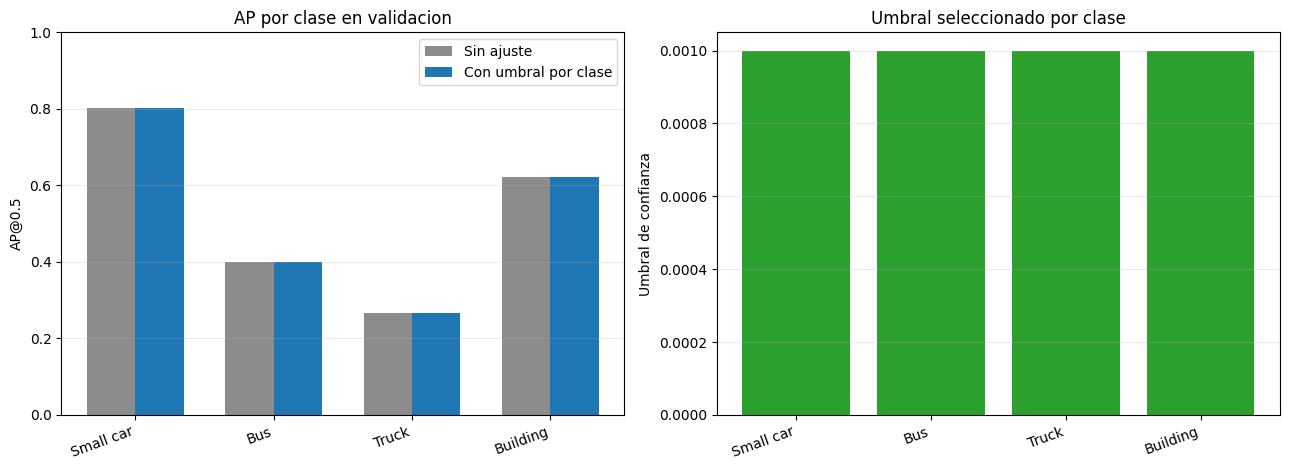

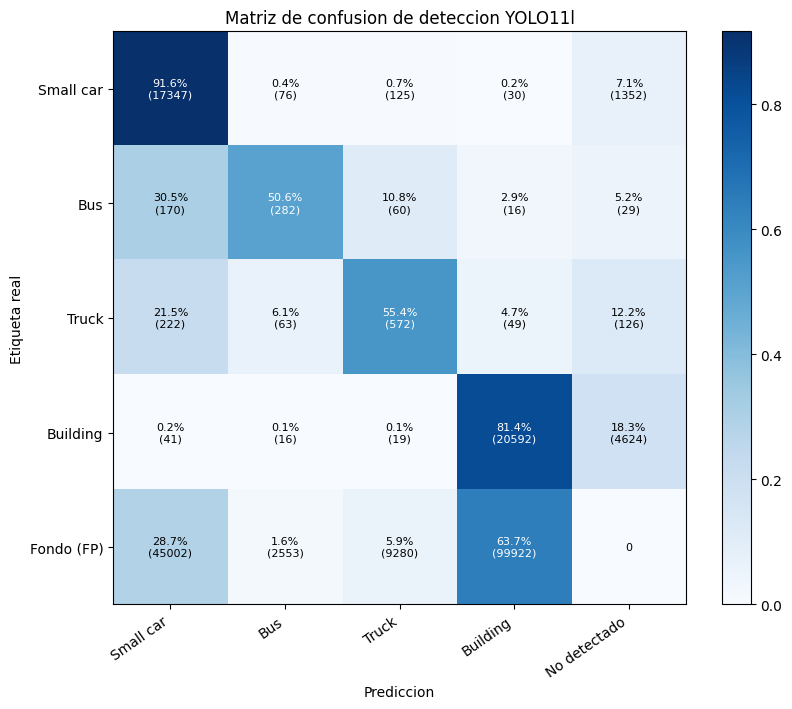

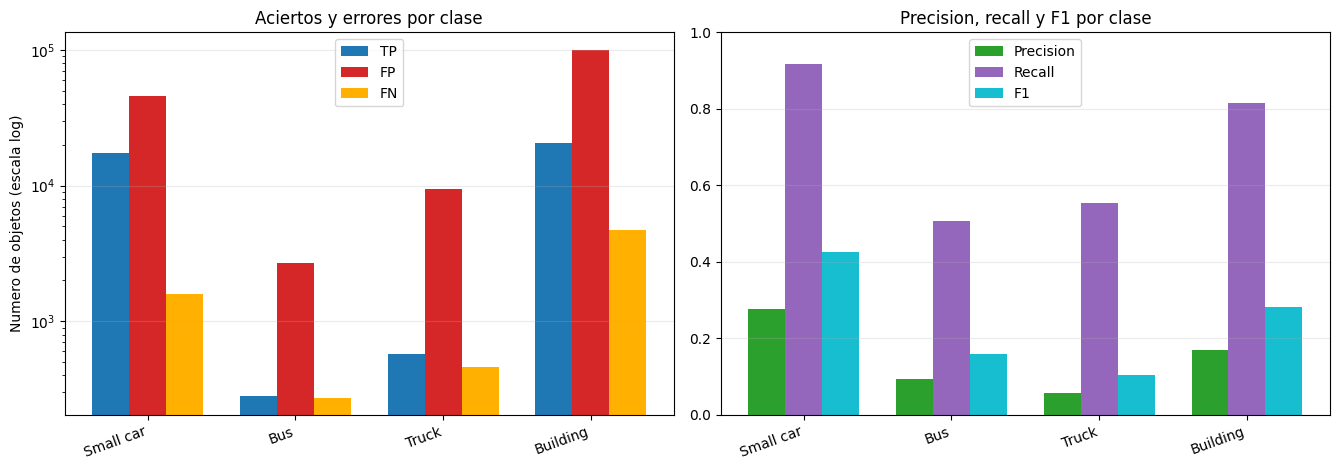

Graficas guardadas en: /kaggle/working/yolo11l_mejorado_diagnostics
- ap_thresholds: /kaggle/working/yolo11l_mejorado_diagnostics/yolo11l_ap_y_umbrales.png
- confusion: /kaggle/working/yolo11l_mejorado_diagnostics/yolo11l_matriz_confusion.png
- tp_fp_fn: /kaggle/working/yolo11l_mejorado_diagnostics/yolo11l_tp_fp_fn_metricas.png


In [8]:
import matplotlib.pyplot as plt
from IPython.display import display

DIAGNOSTIC_DIR = WORKDIR / 'yolo11l_mejorado_diagnostics'
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)


def build_detection_confusion(annotations, predictions, iou_threshold=0.5):
    row_labels = CLASS_NAMES + ['Fondo (FP)']
    col_labels = CLASS_NAMES + ['No detectado']
    row_index = {name: idx for idx, name in enumerate(row_labels)}
    col_index = {name: idx for idx, name in enumerate(col_labels)}
    matrix = np.zeros((len(row_labels), len(col_labels)), dtype=int)
    stats = {cls: {'tp': 0, 'fp': 0, 'fn': 0} for cls in CLASS_NAMES}

    for filename in sorted(set(annotations) | set(predictions)):
        gt_items = []
        for cls in CLASS_NAMES:
            for box in annotations.get(filename, {}).get(cls, {}).get('bbox', []):
                gt_items.append({'class': cls, 'box': np.asarray(box, dtype=float), 'matched': False})

        pred_items = []
        for cls in CLASS_NAMES:
            data = predictions.get(filename, {}).get(cls, {})
            boxes = data.get('bbox', [])
            confs = data.get('confidence', [1.0] * len(boxes))
            for box, conf in zip(boxes, confs):
                pred_items.append({'class': cls, 'box': np.asarray(box, dtype=float), 'score': float(conf)})
        pred_items.sort(key=lambda item: item['score'], reverse=True)

        for pred in pred_items:
            if gt_items:
                ious = np.array([
                    calc_iou(np.asarray([gt['box']], dtype=float), pred['box'])[0] if not gt['matched'] else -1.0
                    for gt in gt_items
                ])
                best_idx = int(np.argmax(ious))
                best_iou = float(ious[best_idx])
            else:
                best_idx = -1
                best_iou = 0.0

            if best_idx >= 0 and best_iou >= iou_threshold:
                true_cls = gt_items[best_idx]['class']
                gt_items[best_idx]['matched'] = True
                matrix[row_index[true_cls], col_index[pred['class']]] += 1
                if true_cls == pred['class']:
                    stats[true_cls]['tp'] += 1
                else:
                    stats[true_cls]['fn'] += 1
                    stats[pred['class']]['fp'] += 1
            else:
                matrix[row_index['Fondo (FP)'], col_index[pred['class']]] += 1
                stats[pred['class']]['fp'] += 1

        for gt in gt_items:
            if not gt['matched']:
                matrix[row_index[gt['class']], col_index['No detectado']] += 1
                stats[gt['class']]['fn'] += 1

    for cls in CLASS_NAMES:
        tp = stats[cls]['tp']
        fp = stats[cls]['fp']
        fn = stats[cls]['fn']
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        stats[cls]['precision'] = precision
        stats[cls]['recall'] = recall
        stats[cls]['f1'] = 2 * precision * recall / max(precision + recall, 1e-9) if precision + recall else 0.0
    return matrix, row_labels, col_labels, stats


def plot_ap_and_thresholds(raw_ap, tuned_ap, thresholds):
    x = np.arange(len(CLASS_NAMES))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    width = 0.35
    axes[0].bar(x - width / 2, [raw_ap[c] for c in CLASS_NAMES], width, label='Sin ajuste', color='#8c8c8c')
    axes[0].bar(x + width / 2, [tuned_ap[c] for c in CLASS_NAMES], width, label='Con umbral por clase', color='#1f77b4')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('AP@0.5')
    axes[0].set_title('AP por clase en validacion')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(x, [thresholds[c] for c in CLASS_NAMES], color='#2ca02c')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    axes[1].set_ylabel('Umbral de confianza')
    axes[1].set_title('Umbral seleccionado por clase')
    axes[1].grid(axis='y', alpha=0.25)
    fig.tight_layout()
    path = DIAGNOSTIC_DIR / 'yolo11l_ap_y_umbrales.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    return path


def plot_confusion_matrix(matrix, row_labels, col_labels):
    row_sums = matrix.sum(axis=1, keepdims=True)
    normalized = matrix.astype(float) / np.maximum(row_sums, 1)
    fig, ax = plt.subplots(figsize=(9.5, 7.2))
    im = ax.imshow(normalized, cmap='Blues')
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=35, ha='right')
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Etiqueta real')
    ax.set_title('Matriz de confusion de deteccion YOLO11l')
    max_value = max(float(normalized.max()), 1e-9)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            count = int(matrix[i, j])
            pct = normalized[i, j] * 100
            label = f'{pct:.1f}%\n({count})' if count else '0'
            ax.text(
                j,
                i,
                label,
                ha='center',
                va='center',
                fontsize=8,
                color='white' if normalized[i, j] > max_value * 0.55 else 'black',
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    path = DIAGNOSTIC_DIR / 'yolo11l_matriz_confusion.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    return path


def plot_tp_fp_fn(stats):
    x = np.arange(len(CLASS_NAMES))
    width = 0.25
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
    tp = np.array([stats[c]['tp'] for c in CLASS_NAMES], dtype=float)
    fp = np.array([stats[c]['fp'] for c in CLASS_NAMES], dtype=float)
    fn = np.array([stats[c]['fn'] for c in CLASS_NAMES], dtype=float)
    axes[0].bar(x - width, np.maximum(tp, 1), width, label='TP', color='#1f77b4')
    axes[0].bar(x, np.maximum(fp, 1), width, label='FP', color='#d62728')
    axes[0].bar(x + width, np.maximum(fn, 1), width, label='FN', color='#ffb000')
    axes[0].set_yscale('log')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    axes[0].set_title('Aciertos y errores por clase')
    axes[0].set_ylabel('Numero de objetos (escala log)')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.25)

    precision = np.array([stats[c]['precision'] for c in CLASS_NAMES], dtype=float)
    recall = np.array([stats[c]['recall'] for c in CLASS_NAMES], dtype=float)
    f1 = np.array([stats[c]['f1'] for c in CLASS_NAMES], dtype=float)
    axes[1].bar(x - width, precision, width, label='Precision', color='#2ca02c')
    axes[1].bar(x, recall, width, label='Recall', color='#9467bd')
    axes[1].bar(x + width, f1, width, label='F1', color='#17becf')
    axes[1].set_ylim(0, 1)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    axes[1].set_title('Precision, recall y F1 por clase')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.25)
    fig.tight_layout()
    path = DIAGNOSTIC_DIR / 'yolo11l_tp_fp_fn_metricas.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    return path


confusion_matrix, confusion_rows, confusion_cols, confusion_stats = build_detection_confusion(
    annotations,
    tuned_predictions,
    iou_threshold=0.5,
)
diagnostic_paths = {
    'ap_thresholds': plot_ap_and_thresholds(raw_ap_by_class, tuned_ap_by_class, score_thresholds),
    'confusion': plot_confusion_matrix(confusion_matrix, confusion_rows, confusion_cols),
    'tp_fp_fn': plot_tp_fp_fn(confusion_stats),
}

print('Graficas guardadas en:', DIAGNOSTIC_DIR)
for name, path in diagnostic_paths.items():
    print(f'- {name}: {path}')


## Prediccion y ZIP de entrega

La inferencia final usa el umbral minimo de los seleccionados en validacion y despues filtra cada clase con su propio umbral. Esto intenta conservar `Bus` y `Truck`, que en el modelo anterior tenian mucho falso negativo.


In [9]:
TEST_IOU_NMS = 0.20
USE_TTA_TEST = True


def load_score_thresholds():
    if THRESHOLDS_PATH.exists():
        with open(THRESHOLDS_PATH, encoding='utf-8') as f:
            loaded = json.load(f)
        return {cls: float(loaded.get(cls, DEFAULT_SCORE_THRESHOLDS.get(cls, 0.01))) for cls in CLASS_NAMES}
    return DEFAULT_SCORE_THRESHOLDS.copy()


weights_path = BEST_WEIGHTS if BEST_WEIGHTS.exists() else LAST_WEIGHTS
if not weights_path.exists():
    raise FileNotFoundError('No se encontro best.pt ni last.pt. Ejecuta primero el entrenamiento.')

model = YOLO(str(weights_path))
score_thresholds = load_score_thresholds()
raw_score_threshold = min(score_thresholds.values())
print('Using score thresholds:', score_thresholds)
print('Raw score threshold:', raw_score_threshold)
print('Using TTA:', USE_TTA_TEST)

predictions_data = {'images': {}, 'annotations': {}, 'categories': categories}
ann_idx = 0

for img_idx, item in enumerate(tqdm(test_converted, desc='Test inference YOLO11l')):
    jpg_path = item['jpg_path']
    original_filename = item['original_filename']
    width = int(item['width'])
    height = int(item['height'])
    image_id = Path(original_filename).name

    result = model.predict(
        source=str(jpg_path),
        imgsz=TRAIN_IMAGE_SIZE,
        conf=raw_score_threshold,
        iou=TEST_IOU_NMS,
        max_det=MAX_DET,
        augment=USE_TTA_TEST,
        verbose=False,
    )[0]

    boxes = result.boxes
    kept = []
    if boxes is not None and len(boxes):
        xyxy = boxes.xyxy.cpu().numpy()
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs = boxes.conf.cpu().numpy()
        for det_idx, (box, cls_id, score) in enumerate(zip(xyxy, cls_ids, confs)):
            if int(cls_id) not in categories:
                continue
            cls_name = categories[int(cls_id)]
            if float(score) >= score_thresholds.get(cls_name, 0.01):
                kept.append((box, int(cls_id), float(score)))

    predictions_data['images'][img_idx] = {
        'image_id': image_id,
        'filename': original_filename,
        'num_objects': int(len(kept)),
        'width': width,
        'height': height,
    }

    for box, cls_id, score in kept:
        x1, y1, x2, y2 = box.tolist()
        predictions_data['annotations'][ann_idx] = {
            'image_id': image_id,
            'category_id': categories[int(cls_id)],
            'bbox': [
                int(np.clip(round(x1), 0, width - 1)),
                int(np.clip(round(y1), 0, height - 1)),
                int(np.clip(round(x2), 0, width - 1)),
                int(np.clip(round(y2), 0, height - 1)),
            ],
            'confidence': float(score),
        }
        ann_idx += 1

prediction_path = WORKDIR / 'prediction_yolo11l_mejorado.json'
submission_path = WORKDIR / 'submission_yolo11l_mejorado.zip'
with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print('Predicciones por clase:', Counter(a['category_id'] for a in predictions_data['annotations'].values()))

try:
    from IPython.display import FileLink, display
    display(FileLink(str(submission_path)))
except Exception:
    pass


Using score thresholds: {'Small car': 0.001, 'Bus': 0.001, 'Truck': 0.001, 'Building': 0.001}
Raw score threshold: 0.001
Using TTA: True


Test inference YOLO11l: 100%|██████████| 852/852 [01:19<00:00, 10.75it/s]


Archivos generados:
/kaggle/working/prediction_yolo11l_mejorado.json - 35437124 bytes
/kaggle/working/submission_yolo11l_mejorado.zip - 5284235 bytes
Predicciones por clase: Counter({'Building': 132489, 'Small car': 69749, 'Truck': 9894, 'Bus': 3261})


/kaggle/working/submission_yolo11l_mejorado.zip

In [10]:
TOTAL_TIME = time.perf_counter() - RUN_START
print(f'Tiempo total: {TOTAL_TIME / 60:.2f} min')
print('Notebook: Prueba5_YOLO11l_Mejorado.ipynb')
print('Submission:', WORKDIR / 'submission_yolo11l_mejorado.zip')
print('Prediction JSON:', WORKDIR / 'prediction_yolo11l_mejorado.json')
print('Best weights:', BEST_WEIGHTS)
print('Thresholds:', THRESHOLDS_PATH)
print('Diagnostics:', DIAGNOSTIC_DIR if 'DIAGNOSTIC_DIR' in globals() else 'No ejecutado')


Tiempo total: 454.41 min
Notebook: Prueba5_YOLO11l_Mejorado.ipynb
Submission: /kaggle/working/submission_yolo11l_mejorado.zip
Prediction JSON: /kaggle/working/prediction_yolo11l_mejorado.json
Best weights: /kaggle/working/yolo11l_mejorado_runs/xview_yolo11l_mejorado/weights/best.pt
Thresholds: /kaggle/working/yolo11l_mejorado_score_thresholds.json
Diagnostics: /kaggle/working/yolo11l_mejorado_diagnostics
